In [67]:
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter, NullFormatter, ScalarFormatter
import numpy as np
import pandas as pd
import seaborn as sb
import seaborn.objects as so

nCells = {"LDC-S": 1030301, "LDC-M": 8120601, "Wind": 6517376}
cases = {"LDC-S": "Lid-Driven-Cavity S", "LDC-M": "Lid-Driven-Cavity M", "Wind": "WindsorBody"}

df = pd.read_csv("results/results_new.csv", skip_blank_lines=True)
normd = []
for ms, case in zip(df["time_mean_ms"], df["case_short"]):
    normd.append(ms*1000000 / nCells[case])
df["time_mean_ns_normed"] = normd
filtered = df[~df["variant"].str.contains("Only")]
sorted_variants = sorted(df["variant"].unique())
sorted_variants_filtered = sorted(filtered["variant"].unique())

In [165]:
def float_to_power10(x):
    s = f"{x:.6e}"          # scientific notation string
    mantissa, exp = s.split('e')
    if round(float(mantissa), 1) == 1.0:
        return fr"$10^{int(exp)}$"
    else:
        return fr"${round(float(mantissa), 1)}10^{int(exp)}$"
def add_yticks_suffix(ax, suffix, toExp=True):
    ticks = ax.get_yticks()
    suffixed = [""]*len(ticks)
    for i in range(len(ticks)):
        x = ticks[i]
        if toExp:
            x = float_to_power10(x)
        else:
            x = str(int(x))
        suffixed[i] = x + suffix

    ax.yaxis.set_ticklabels(suffixed)

In [140]:
float_to_power10(1000)

'1.0x10^3'

In [68]:
df

,time_mean_ms,time_median_ms,gc_time_mean_ms,gc_time_median_ms,case_short,case_long,strategy,variant,language,time_mean_ns_normed
0,99.812780,101.696720,4.098518,0.0,LDC-S,LDC-S,faceBased,DivOnlyDynamicCDF,julia,96.877301
1,105.409200,103.057816,8.083513,0.0,LDC-S,LDC-S,faceBased,PrecalculatedWeightsUpwind,julia,102.309131
2,102.978250,101.667290,3.029836,0.0,LDC-S,LDC-S,faceBased,DivOnlyHardCodedUpwind,julia,99.949675
3,42.974182,33.386826,9.064015,0.0,LDC-S,LDC-S,faceBased,LaplaceOnly,julia,41.710318
4,101.436844,96.292114,4.461367,0.0,LDC-S,LDC-S,faceBased,DynamicCDF,julia,98.453601
...,...,...,...,...,...,...,...,...,...,...
112,1671.027600,1670.865800,0.000000,0.0,LDC-M,LDC-M,cellBased,DivOnlyPrecalculatedWeightsUpwind,julia,205.776346
113,1549.805000,1538.788800,14.032230,0.0,LDC-M,LDC-M,cellBased,DivOnlyDynamicUpwind,julia,190.848559
114,1722.432000,1720.603300,0.000000,0.0,LDC-M,LDC-M,cellBased,PrecalculatedWeightsCDF,julia,212.106468
115,1565.566900,1552.270400,13.411845,0.0,LDC-M,LDC-M,cellBased,DynamicUpwind,julia,192.789536


In [168]:
def draw_boxplot(data, x, y, save=False, annotate=False, useLog=False, ylabel="", xlabel="",ax=None):
    yl = ylabel or y
    xl = xlabel or x
    if ax:
        plot = sb.boxplot(data=data, ax=ax, x=x, y=y, log_scale=useLog, gap=.1).set(
            ylabel=yl, xlabel=xl
        )
    else:
        plot = sb.boxplot(data=data, x=x, y=y, log_scale=useLog, gap=.1).set(
            ylabel=yl, xlabel=xl
        )
    if annotate:
        minvals = data.loc[data.groupby("strategy")["time_mean_ms"].idxmin()]
        mapping = {"faceBased": 0, "globalFaceBased": 1, "cellBased": 2}
        for i, row in minvals.iterrows():
            plot.annotate(row["variant"],
                    xy=(mapping[row["strategy"]], row[y]),
                    fontsize=12)
    if save:
        plt.savefig(f"figures/{save}.svg")

/tmp/ipykernel_27517/2644124621.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(suffixed)
/tmp/ipykernel_27517/2644124621.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(suffixed)
/tmp/ipykernel_27517/2644124621.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(suffixed)


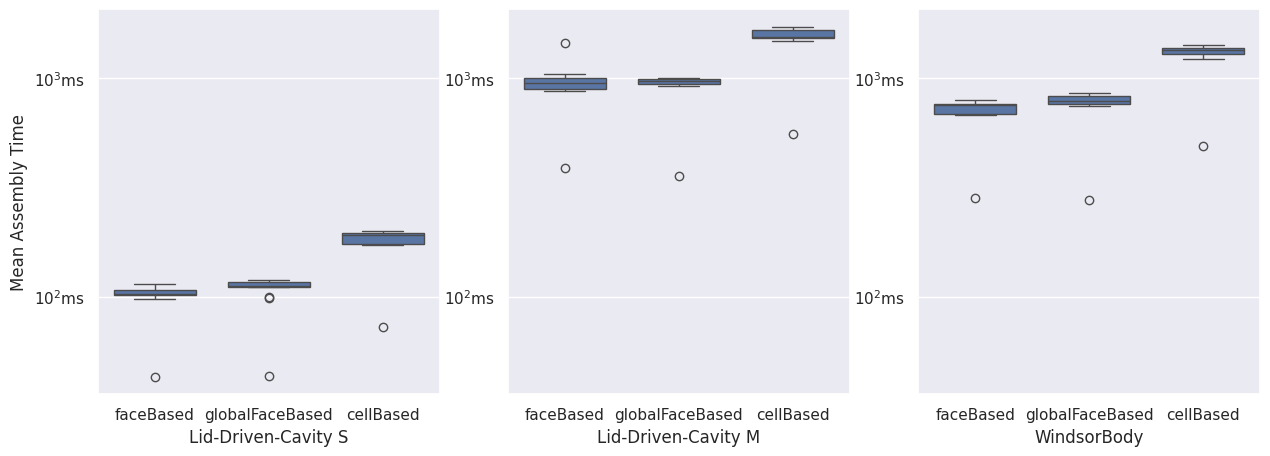

In [163]:
fig, axes = plt.subplots(1,3, figsize=(15, 5), sharey=True)
for i, ax in enumerate(axes.flat):
    case_df = df[df["case_short"] == list(cases.keys())[i]]
    draw_boxplot(case_df, ax=ax, x="strategy", y="time_mean_ms", save=False, annotate=False, xlabel=list(cases.values())[i], useLog=True, ylabel="Mean Assembly Time")
    ax.yaxis.set_tick_params(labelleft=True)
    add_yticks_suffix(ax=ax, suffix="ms")

/tmp/ipykernel_27517/2923366963.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(suffixed)
/tmp/ipykernel_27517/2923366963.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(suffixed)
/tmp/ipykernel_27517/2923366963.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(suffixed)


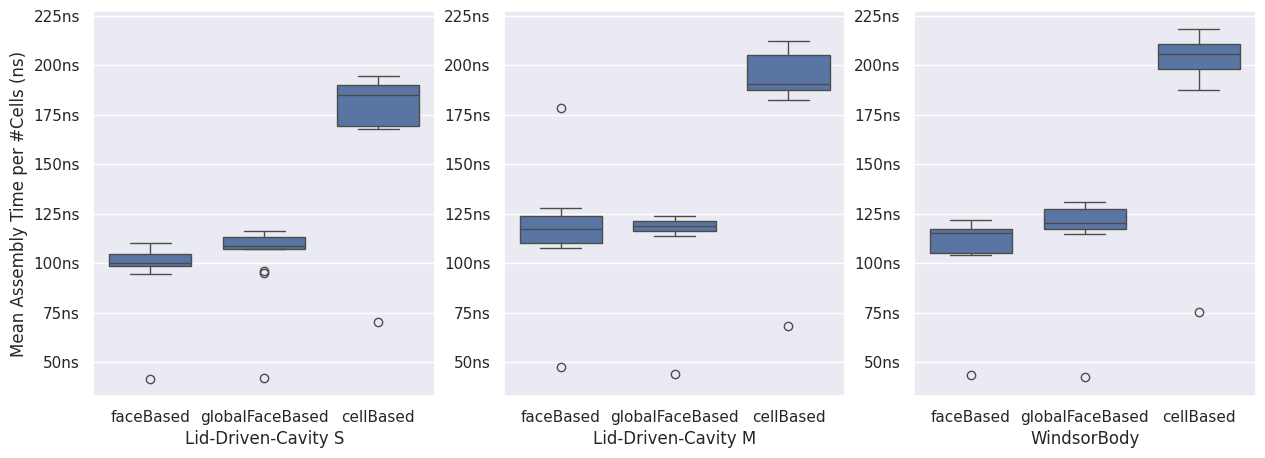

In [166]:
fig, axes = plt.subplots(1,3, figsize=(15, 5), sharey=True)
for i, ax in enumerate(axes.flat):
    case_df = df[df["case_short"] == list(cases.keys())[i]]
    draw_boxplot(case_df, ax=ax, x="strategy", y="time_mean_ns_normed", save=False, annotate=False, xlabel=list(cases.values())[i], ylabel="Mean Assembly Time per #Cells (ns)")
    ax.yaxis.set_tick_params(labelleft=True)
    add_yticks_suffix(ax, "ns", toExp=False)

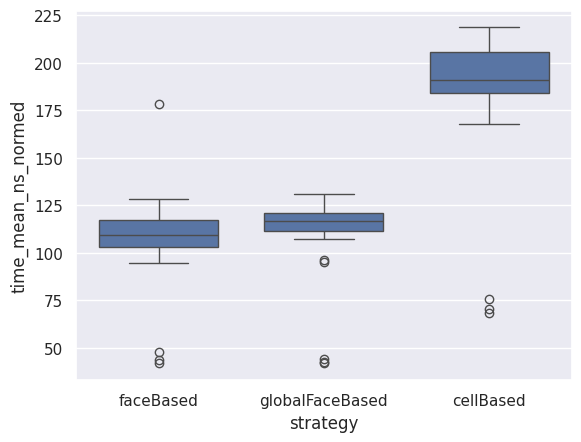

In [167]:
draw_boxplot(df, x="strategy", y="time_mean_ns_normed", save=False, annotate=False)

In [73]:
filtered

,time_mean_ms,time_median_ms,gc_time_mean_ms,gc_time_median_ms,case_short,case_long,strategy,variant,language,time_mean_ns_normed
1,105.409200,103.057816,8.083513,0.0,LDC-S,LDC-S,faceBased,PrecalculatedWeightsUpwind,julia,102.309131
4,101.436844,96.292114,4.461367,0.0,LDC-S,LDC-S,faceBased,DynamicCDF,julia,98.453601
7,113.694130,111.922990,4.249827,0.0,LDC-S,LDC-S,faceBased,HardCodedUpwind,julia,110.350402
10,102.538000,96.493910,4.994685,0.0,LDC-S,LDC-S,faceBased,PrecalculatedWeightsCDF,julia,99.522373
11,102.518670,97.210900,5.056023,0.0,LDC-S,LDC-S,faceBased,HardCodedCDF,julia,99.503611
12,113.017190,107.462036,4.427753,0.0,LDC-S,LDC-S,faceBased,DynamicUpwind,julia,109.693371
14,119.426460,114.799050,4.169004,0.0,LDC-S,LDC-S,globalFaceBased,PrecalculatedWeightsUpwind,julia,115.914145
17,114.270920,108.676490,3.471211,0.0,LDC-S,LDC-S,globalFaceBased,DynamicCDF,julia,110.910229
20,116.835890,111.536224,4.088986,0.0,LDC-S,LDC-S,globalFaceBased,HardCodedUpwind,julia,113.399764
23,119.829960,115.569180,4.159248,0.0,LDC-S,LDC-S,globalFaceBased,PrecalculatedWeightsCDF,julia,116.305779


/tmp/ipykernel_27517/2606667637.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(suffixed)


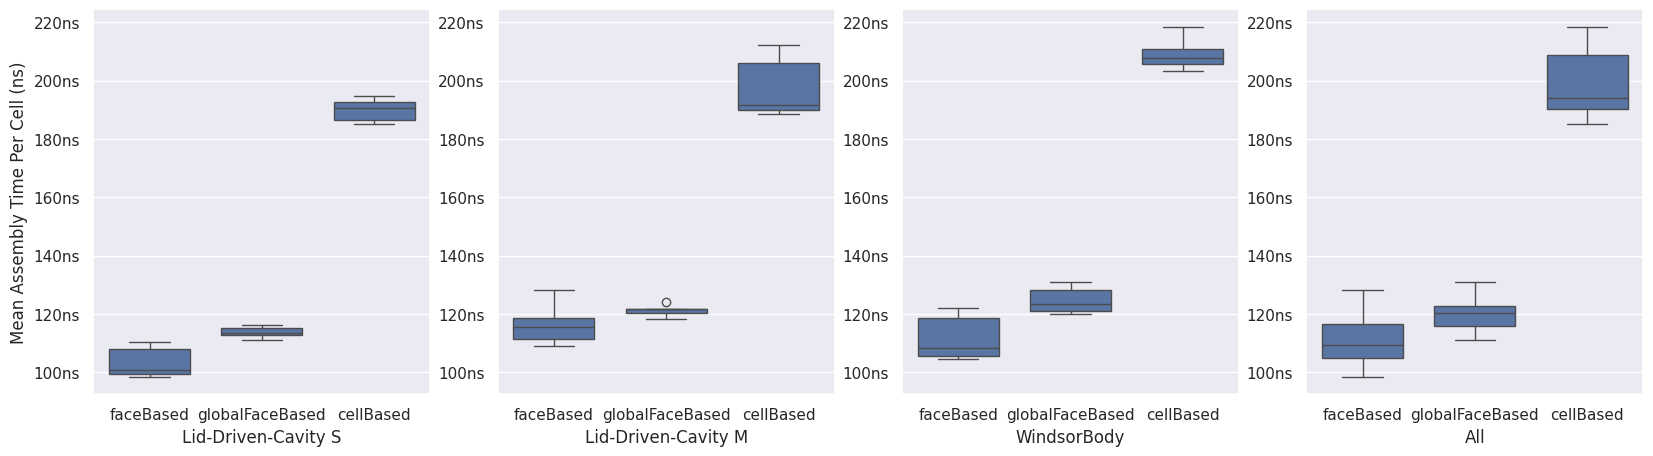

In [ ]:
fig, axes = plt.subplots(1,4, figsize=(20, 5), sharey=True)
for i, ax in enumerate(axes.flat[0:3]):
    case_df = filtered[filtered["case_short"] == list(cases.keys())[i]]
    draw_boxplot(case_df, ax=ax, x="strategy", y="time_mean_ns_normed", save=False, annotate=False, xlabel=list(cases.values())[i], ylabel="Mean Assembly Time Per Cell (ns)")
    ax.yaxis.set_tick_params(labelleft=True)
draw_boxplot(filtered, ax=axes.flat[3], x="strategy", y="time_mean_ns_normed", save=False, annotate=False, xlabel="All", ylabel="Mean Assembly Time Per Cell (ns)")
axes.flat[3].yaxis.set_tick_params(labelleft=True)
add_yticks_suffix(axes.flat[1], "ns")


time_mean_ms Mean Assembly Time (ms)
time_mean_ns_normed Mean Assembly Time Per Cell (ms)


/tmp/ipykernel_27517/423237425.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  p.set_xticklabels(p.get_xticklabels(),
/tmp/ipykernel_27517/423237425.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  p.set_xticklabels(p.get_xticklabels(),


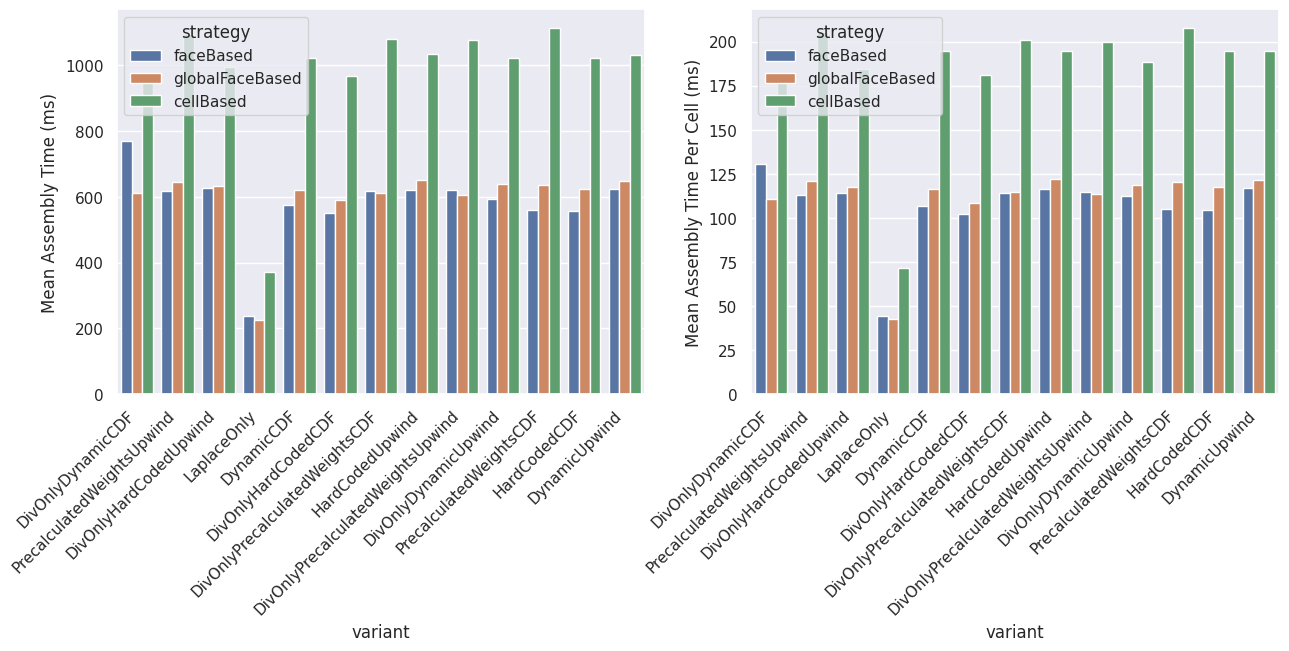

In [75]:
fig, axes = plt.subplots(1,2, figsize=(15, 5))

for i, ax in enumerate(axes.flat):
    y = "time_mean_ms" if i == 0 else "time_mean_ns_normed"
    yl = "Mean Assembly Time (ms)" if i == 0 else "Mean Assembly Time Per Cell (ms)"
    print(y,yl)
    p =  sb.barplot(df, ax=ax, x="variant", y=y, hue="strategy", errorbar=None)
    p.set(
        ylabel=yl,
    )

    p.set_xticklabels(p.get_xticklabels(), 
                            rotation=45, 
                            horizontalalignment='right'
    )


/tmp/ipykernel_27517/2109296393.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  p.set_xticklabels(p.get_xticklabels(),


<class 'matplotlib.text.Text'>
<class 'matplotlib.text.Text'>
<class 'matplotlib.text.Text'>


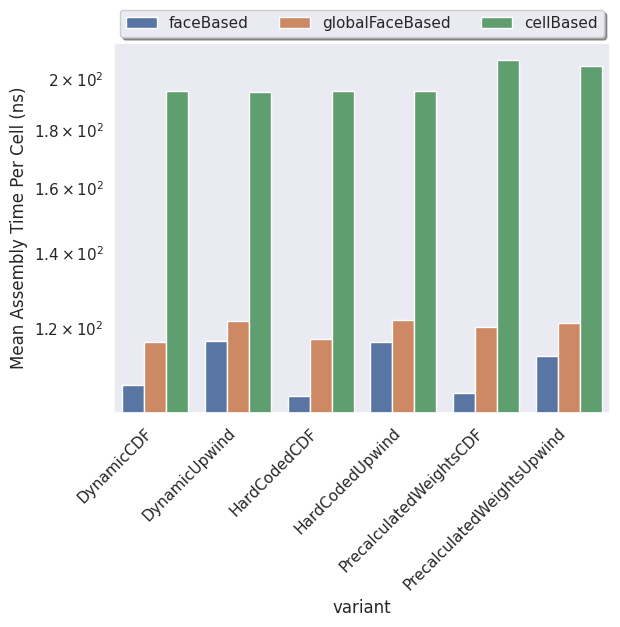

In [76]:
sb.set_theme()
fig, ax= plt.subplots()
y = "time_mean_ns_normed"
yl = "Mean Assembly Time Per Cell (ns)"
p =  sb.barplot(filtered,ax=ax ,x="variant", y=y, hue="strategy", legend="brief", order=sorted_variants_filtered, errorbar=None)
p.set_yscale("log")
p.set(
    ylabel=yl
)

p.set_xticklabels(p.get_xticklabels(), 
                        rotation=45, 
                        horizontalalignment='right'
)
labels = ax.get_legend_handles_labels()[1]
ax.legend().remove()

for t, new_label in zip(ax.legend().texts, labels):
    print(type(t))
    t.set_text(new_label)
handles, labels = axes[0].get_legend_handles_labels()
plt.legend(handles, labels, loc="upper center", bbox_to_anchor = (0.5,1.11),ncol=6, fancybox=True, shadow=True)
plt.savefig(f"figures/test.svg")
